In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
import itertools
import warnings
from statsmodels.stats.diagnostic import acorr_ljungbox
from numpy.polynomial import polynomial as P



In [3]:
df = pd.read_csv("/Users/cyriaque/timeseries-arma-sarima-forecast/serie", sep= " ", header=None, names=["t", "Xt"])

The model is as follow : X(t) = m(t) + s(t) + Y(t)

where:
- E[Y(t)]=0
- s(t+d) = s(t)
- sum from j=1 to d of s(j) = 0

here d=12 from EDA. Hence q = 6.



Tendency estimation :

Since d is even we can use the following estimator : m(t) = [0.5x_(t-6) + x_(t-5) + ... + x_(t+6)] / 12

In [4]:
weights = np.array([0.5] +[1]*11 + [0.5]) /12
df["trend"] = df["Xt"].rolling(window=13, center=True).apply(lambda x: np.dot(x,weights))
df["trend"].dropna()

6       1.619913
7       1.634055
8       1.598731
9       1.489988
10      1.296460
         ...    
989    10.905636
990    10.965765
991    10.901362
992    10.732093
993    10.687181
Name: trend, Length: 988, dtype: float64

Seasonality estimation :

We can use the following estimator : s(k) = w(k) - mean of w(k)

for k=1,...,d

s(k) = w(k) - mean of w(k)

where w(k) is the average deviation from the trend

In [5]:
df["detrended"] = df["Xt"]-df["trend"]
df["season"] = df.index % 12 +1

w = df.groupby("season")["detrended"].mean()

s_hat = w-w.mean()

df["seasonal"] = df["season"].map(s_hat)
df["de-seasoned"] = df["Xt"] -df["seasonal"]
df["residuals"] = df["Xt"] -df["seasonal"] - df["trend"]

In [84]:
df[12:24]

,t,Xt,trend,detrended,season,seasonal,de-seasoned,residuals,Yt
12,13,4.840691,0.696627,4.144064,1,2.721940,2.118751,1.422124,1.422124
13,14,3.279333,0.468567,2.810766,2,2.852543,0.426790,-0.041777,-0.041777
14,15,2.509693,0.363516,2.146178,3,2.122928,0.386765,0.023250,0.023250
15,16,1.890566,0.445941,1.444625,4,0.645997,1.244568,0.798628,0.798628
16,17,0.027689,0.493801,-0.466113,5,-0.811249,0.838937,0.345136,0.345136
17,18,-2.114110,0.412169,-2.526279,6,-2.010474,-0.103637,-0.515806,-0.515806
18,19,-3.001775,0.332549,-3.334324,7,-2.531433,-0.470342,-0.802891,-0.802891
19,20,-3.461251,0.377170,-3.838421,8,-2.551163,-0.910088,-1.287257,-1.287257
20,21,-2.767181,0.480130,-3.247312,9,-1.948850,-0.818331,-1.298462,-1.298462
21,22,-0.406509,0.507584,-0.914093,10,-0.862243,0.455734,-0.051850,-0.051850


In [7]:
result = seasonal_decompose(df["Xt"], model="additive", period=12)

In [8]:
result.trend[5:15]


5          NaN
6     1.619913
7     1.634055
8     1.598731
9     1.489988
10    1.296460
11    0.994970
12    0.696627
13    0.468567
14    0.363516
Name: trend, dtype: float64

In [9]:
result.seasonal[5:15]


5    -2.010474
6    -2.531433
7    -2.551163
8    -1.948850
9    -0.862243
10    0.581009
11    1.790995
12    2.721940
13    2.852543
14    2.122928
Name: seasonal, dtype: float64

We got the same results re-computing from scratch and with the statsmodels library.

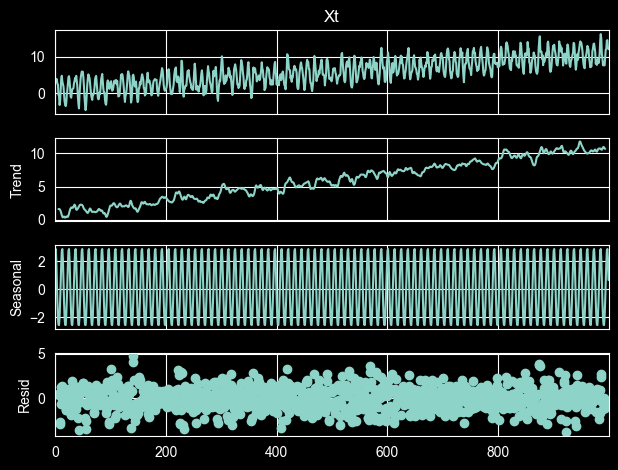

In [10]:
result.plot()
plt.show()

In [11]:
df["Yt"]= df["Xt"] - df["trend"] - df["seasonal"]

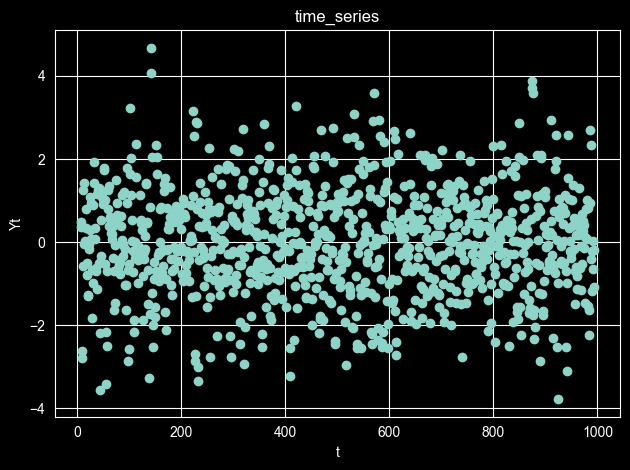

In [12]:
plt.scatter(df["t"][0:1000], df["Yt"][0:1000])
plt.title("time_series")
plt.xlabel("t")
plt.ylabel("Yt")
plt.tight_layout()
plt.show()

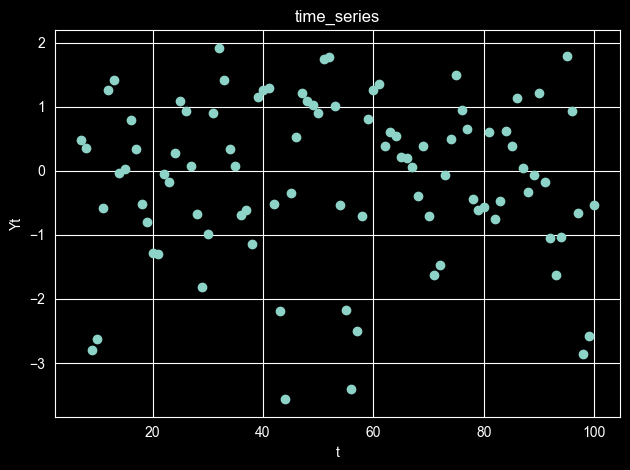

In [13]:
plt.scatter(df["t"][0:100], df["Yt"][0:100])
plt.title("time_series")
plt.xlabel("t")
plt.ylabel("Yt")
plt.tight_layout()
plt.show()

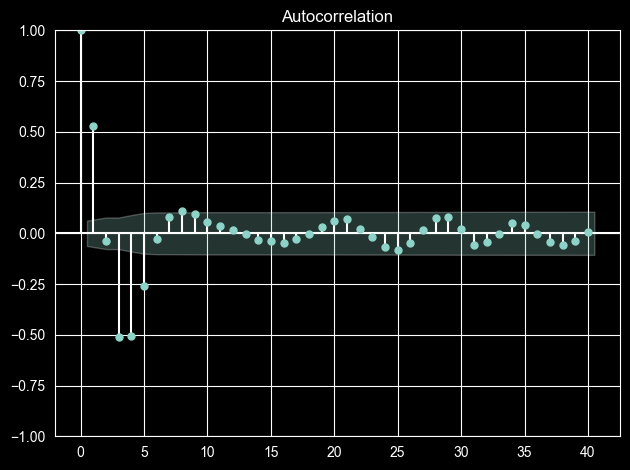

In [14]:
plot_acf(df["Yt"].dropna(), lags=40)
plt.tight_layout()
plt.show()

The ACF drops immediately to near zero and stay in the confidence band so we can assume that the series is stationary.
We can check if our assumption is correct with the Dickey  and Fuller test.

H0 : The series has a unit root --> non-stationarity

H1 : The series is stationary


In [15]:
result = adfuller(df["Yt"].dropna())
print(f"ADF statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

ADF statistic: -12.6080
p-value: 0.0000


In [16]:
result

(np.float64(-12.6079832505304),
 np.float64(1.6794135470670336e-23),
 21,
 966,
 {'1%': np.float64(-3.437137538234527),
  '5%': np.float64(-2.8645366106945414),
  '10%': np.float64(-2.568365556798649)},
 np.float64(2297.545376314163))

Here the p-value is less than 0.05 so we can reject H0. Hence the series is likely stationary, meaning that we can consider using an ARMA to estimate the series. It is consistent with what we observed from the ACF plot.

Identify p and q for the ARMA(p,q) :

In [42]:
warnings.filterwarnings("ignore")

best_aic = np.inf
best_bic = np.inf
best_order_aic = None
best_order_bic = None
results = []

for p,q  in itertools.product(range(6),range(6)):
    try :
        model = ARIMA(df["Yt"].dropna(), order = (p,0,q)).fit()
        results.append({"p" : p, "q" : q, "AIC" : round(model.aic,2), "BIC" : round(model.bic,2)})
        if model.aic < best_aic:
            best_aic = model.aic
            best_order_aic = (p,q)
        if model.bic < best_bic:
            best_bic = model.bic
            best_order_bic = (p,q)
    except:
        continue

print(f"Best order (AIC): ARMA{best_order_aic}, AIC={best_aic:.2f}")
print(f"Best order (BIC: ARMA{best_order_bic}, BIC={best_bic:.2f}")



Best order (AIC): ARMA(5, 3), AIC=2302.02
Best order (BIC: ARMA(2, 3), BIC=2347.89


In [53]:
AIC_BIC_df = pd.DataFrame(results).sort_values("BIC")
AIC_BIC_df

,p,q,AIC,BIC
15,2,3,2313.62,2347.89
16,2,4,2311.18,2350.34
33,5,3,2302.02,2350.98
17,2,5,2307.23,2351.29
21,3,3,2314.25,2353.41
27,4,3,2311.04,2355.10
31,5,1,2316.51,2355.68
34,5,4,2305.61,2359.46
22,3,4,2319.86,2363.92
35,5,5,2307.96,2366.71


In [ ]:
warnings.filterwarnings("ignore")

best_aic = np.inf
best_bic = np.inf
best_order_aic = None
best_order_bic = None

for p,q  in itertools.product(range(10),range(10)):
    try :
        model = ARIMA(df["Yt"].dropna(), order = (p,0,q)).fit()
        if model.aic < best_aic:
            best_aic = model.aic
            best_order_aic = (p,q)
        if model.bic < best_bic:
            best_bic = model.bic
            best_order_bic = (p,q)
    except:
        continue

print(f"Best order (AIC): ARMA{best_order_aic}, AIC={best_aic:.2f}")
print(f"Best order (BIC: ARMA{best_order_bic}, BIC={best_bic:.2f}")



In [ ]:
warnings.filterwarnings("ignore")

best_aic = np.inf
best_bic = np.inf
best_order_aic = None
best_order_bic = None

for p,q  in itertools.product(range(15),range(15)):
    try :
        model = ARIMA(df["Yt"].dropna(), order = (p,0,q)).fit()
        if model.aic < best_aic:
            best_aic = model.aic
            best_order_aic = (p,q)
        if model.bic < best_bic:
            best_bic = model.bic
            best_order_bic = (p,q)
    except:
        continue

print(f"Best order (AIC): ARMA{best_order_aic}, AIC={best_aic:.2f}")
print(f"Best order (BIC: ARMA{best_order_bic}, BIC={best_bic:.2f}")



We prefer the BIC criterion over the AIC because it is asymptotically consistent, whereas the AIC has a positive probability of selecting an overfitted model asymptotically.

We can observe that when we try to minimize the BIC for p,q ∈ {0,..,15} we get an MA(10) with a BIC of 2297 and for p,q ∈ {0,..,5} we get an ARMA(2,3) with a BIC of 2347.

The BIC of an the MA(10) is clearly lower than for an ARMA(2,3)



In [21]:
model_MA_10 = ARIMA(df["Yt"].dropna(), order=(0, 0, 10)).fit()
print(model_MA_10.summary())

/Users/cyriaque/.local/share/virtualenvs/cyriaque-yWP8__sC/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


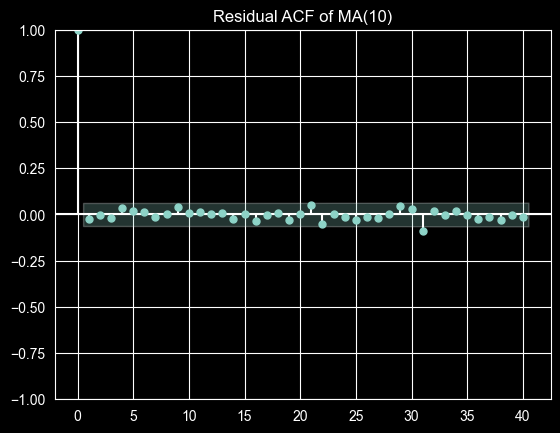

In [22]:
residuals_MA_10 = model_MA_10.resid

plot_acf(residuals_MA_10, lags=40)
plt.title("Residual ACF of MA(10)")
plt.show()

In [73]:
model_ARMA_2_3 = ARIMA(df["Yt"].dropna(), order=(2, 0, 3)).fit()
print(model_ARMA_2_3.summary())

                               SARIMAX Results                                
Dep. Variable:                     Yt   No. Observations:                  988
Model:                 ARIMA(2, 0, 3)   Log Likelihood               -1149.812
Date:                Sun, 24 May 2026   AIC                           2313.625
Time:                        16:36:19   BIC                           2347.895
Sample:                             0   HQIC                          2326.658
                                - 988                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -6.637e-05      0.000     -0.232      0.817      -0.001       0.000
ar.L1          1.0304      0.037     27.808      0.000       0.958       1.103
ar.L2         -0.5924      0.037    -16.157      0.0

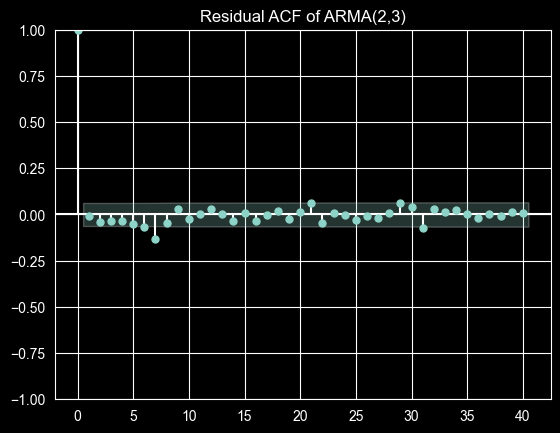

In [47]:
residuals_ARMA_2_3 = model_ARMA_2_3.resid

plot_acf(residuals_ARMA_2_3, lags=40)
plt.title("Residual ACF of ARMA(2,3)")
plt.show()

The residual ACF of the MA(10) model looks closer to white noise than that of the ARMA(2,3) model. Indeed, almost all spikes of the MA(10) are inside the confidence band, except at lags 21 and 31, whereas for the ARMA(2,3), we can observe many spikes outside the band.

Therefore, we can assume that the MA(10) captures the structure of Yt  better

We can run a portmanteau test in order to check our assumption.

In the course we have seen the Box-Pierce test : Q_BP = n * ∑ from k=1 to h of rho_k^hat^2


However according to some empirical test have shown that : "the distribution for the Ljung-Box statistic is closer to a chi2_(h) distribution than is the distribution for the Box-Pierce statistic for all sample sizes including small ones."

https://en.wikipedia.org/wiki/Ljung–Box_test

Let's try both !


In [25]:
lb = acorr_ljungbox(residuals_MA_10, lags=20, return_df=True, boxpierce=True)
print(lb)

     lb_stat  lb_pvalue   bp_stat  bp_pvalue
1   0.542941   0.461216  0.541296   0.461896
2   0.543461   0.762060  0.541813   0.762688
3   0.854662   0.836353  0.851443   0.837127
4   1.940159   0.746764  1.930361   0.748566
5   2.221027   0.817793  2.209243   0.819500
6   2.362019   0.883579  2.349096   0.884959
7   2.484865   0.928232  2.470825   0.929278
8   2.501984   0.961638  2.487771   0.962299
9   4.282694   0.891841  4.248696   0.894295
10  4.336893   0.930872  4.302238   0.932684
11  4.453200   0.954740  4.417017   0.956095
12  4.453725   0.973790  4.417535   0.974671
13  4.509514   0.984467  4.472478   0.985049
14  5.132332   0.983884  5.085231   0.984591
15  5.144809   0.990828  5.097493   0.991268
16  6.357452   0.983754  6.288089   0.984674
17  6.384962   0.990203  6.315070   0.990806
18  6.452317   0.993989  6.381065   0.994390
19  7.241626   0.992809  7.153631   0.993348
20  7.262947   0.995729  7.174478   0.996072


In [26]:
lb = acorr_ljungbox(residuals_ARMA_2_3, lags=20, return_df=True, boxpierce=True)
print(lb)

      lb_stat  lb_pvalue    bp_stat  bp_pvalue
1    0.072575   0.787624   0.072355   0.787939
2    1.572999   0.455436   1.566717   0.456869
3    2.693166   0.441390   2.681226   0.443427
4    4.071981   0.396352   4.051685   0.399056
5    6.707464   0.243321   6.668534   0.246482
6   11.371554   0.077550  11.294934   0.079678
7   29.487008   0.000118  29.245701   0.000130
8   31.780172   0.000102  31.515702   0.000114
9   32.614578   0.000156  32.340837   0.000174
10  33.181422   0.000254  32.900811   0.000283
11  33.194869   0.000489  32.914081   0.000543
12  33.974718   0.000681  33.682902   0.000757
13  33.975728   0.001214  33.683897   0.001344
14  35.391201   0.001286  35.076493   0.001432
15  35.452809   0.002119  35.137043   0.002351
16  36.579687   0.002402  36.243432   0.002676
17  36.595379   0.003816  36.258823   0.004235
18  36.931828   0.005349  36.588475   0.005926
19  37.502190   0.006862  37.146739   0.007606
20  37.724994   0.009566  37.364592   0.010578


Remark : the first 2 columns represent the Ljung-box test and the the 2 last are for the Box-Pierce test.

The Ljung_box test is as follow :

H0 : rho_1 = ... = rho_h = 0 (residuals are a white noise)

H1 : there exist j ∈ {1,..,h} such that rho_j ≠ 0 (remaining autocorrelation)

We can see that all p-value are greater than 0.05 for the model MA(10) but a lot of p-value are less than 0.05 for the model ARMA(2,3).

Hence we cannot reject H0 for the model MA(10) so we can conclude that residuals are white noise and that the model is well-specified

However we reject H0 for the model ARMA(2,3) so we can conclude that there is still autocorrelation in residuals, meaning that the model is misspecified.

The residual ACF and the Ljung-Box (and Box-Pierce) tests both confirm that the MA(10) residuals are white noise, validating the model specification.

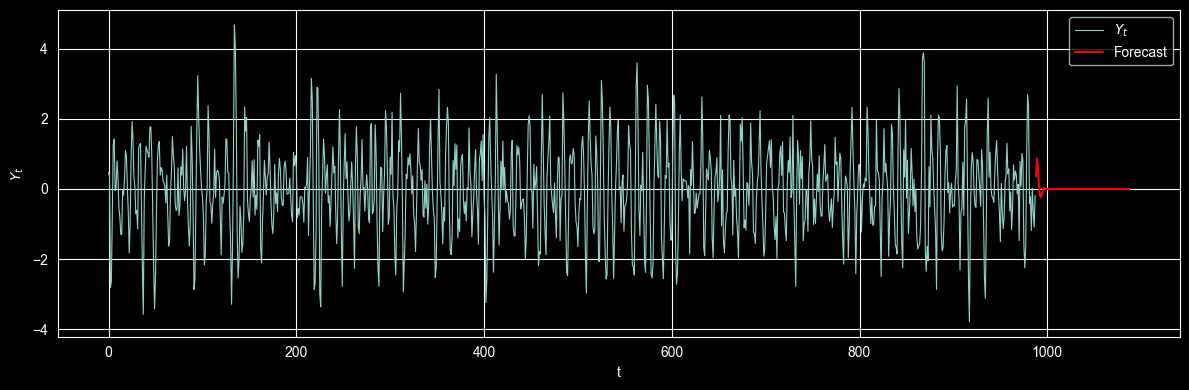

In [109]:
forecast_MA_10 = model_MA_10.forecast(steps=100)

plt.figure(figsize=(12, 4))
plt.plot(df["Yt"].dropna().values, label="$Y_t$", linewidth=0.8)
plt.plot(range(len(df["Yt"].dropna()), len(df["Yt"].dropna()) + 100),
         forecast_MA_10, label="Forecast", color="red")
plt.xlabel("t")
plt.ylabel("$Y_t$")
plt.legend()
plt.tight_layout()
plt.show()


In [107]:
(forecast_MA_10.head(200))

994     0.359647
995     0.871842
996     0.638902
997     0.145781
998    -0.163984
          ...   
1089   -0.000031
1090   -0.000031
1091   -0.000031
1092   -0.000031
1093   -0.000031
Name: predicted_mean, Length: 100, dtype: float64

Actually while prediction can propagate arbritarily far into the future with an AR(p) model since the model depends on past observed values, it is not the case with MA(q). For an MA(q) we can at most predict q periods before it starts to only forecast the mean.

**à supprimer en fait ???**

**à supprimer en fait ???**

**à supprimer en fait ???**

**à supprimer en fait ???**

**à supprimer en fait ???**

**à supprimer en fait ???**


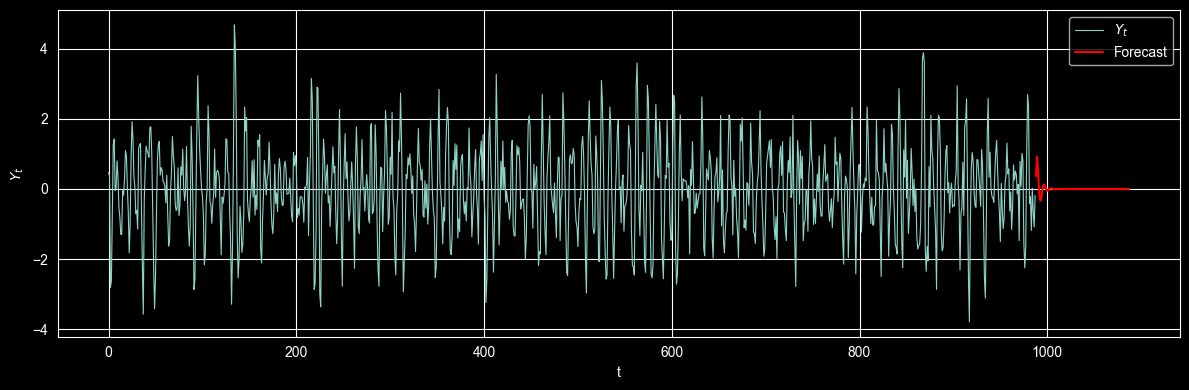

In [59]:
forecast_ARMA_2_3 = model_ARMA_2_3.forecast(steps=100)

plt.figure(figsize=(12, 4))
plt.plot(df["Yt"].dropna().values, label="$Y_t$", linewidth=0.8)
plt.plot(range(len(df["Yt"].dropna()), len(df["Yt"].dropna()) + 100),
         forecast_ARMA_2_3, label="Forecast", color="red")
plt.xlabel("t")
plt.ylabel("$Y_t$")
plt.legend()
plt.tight_layout()
plt.show()


In [110]:
forecast_ARMA_2_3.head(200)

994     0.359854
995     0.925461
996     0.586633
997     0.056191
998    -0.289650
          ...   
1089   -0.000066
1090   -0.000066
1091   -0.000066
1092   -0.000066
1093   -0.000066
Name: predicted_mean, Length: 100, dtype: float64

In [81]:
# Target prediction window: pandas indices 1000..1099 (t = 1001..1100)
idx_future = np.arange(1000, 1100)

# 1. Trend extrapolation on the actual pandas index (not local 0..987)
t_obs = df["trend"].dropna().index.values    # 6..993
m_obs = df["trend"].dropna().values
coeffs = np.polyfit(t_obs, m_obs, deg=1)
m_future = np.polyval(coeffs, idx_future)

# 2. Seasonal aligned with the pandas index (period 12, seasons 1..12)
s_future = np.array([s_hat.loc[(i % 12) + 1] for i in idx_future])

# 3. Yt forecast on indices 1000..1099 directly (NOT 994..1093)
y_future_MA   = model_MA_10.predict(start=1000, end=1099).values
y_future_ARMA = model_ARMA_2_3.predict(start=1000, end=1099).values

# 4. Final
X_future_MA   = m_future + s_future + y_future_MA
X_future_ARMA = m_future + s_future + y_future_ARMA

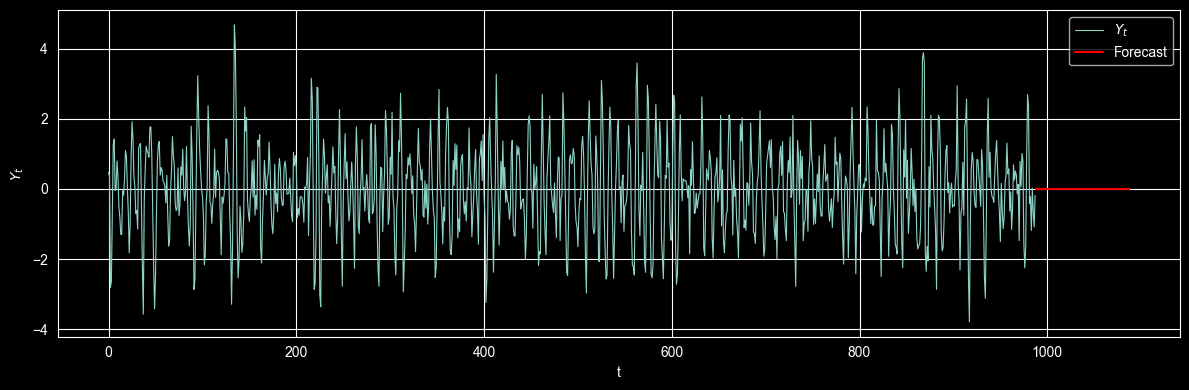

In [114]:
plt.figure(figsize=(12, 4))
plt.plot(df["Yt"].dropna().values, label="$Y_t$", linewidth=0.8)
plt.plot(range(len(df["Yt"].dropna()), len(df["Yt"].dropna()) + 100),
         y_future_MA, label="Forecast", color="red")
plt.xlabel("t")
plt.ylabel("$Y_t$")
plt.legend()
plt.tight_layout()
plt.show()


In [117]:
y_future_ARMA

array([-7.07129640e-02, -1.11740986e-01, -8.77355483e-02, -2.20573853e-02,
        3.20723447e-02,  5.69966151e-02,  4.24905650e-02,  1.30863776e-02,
       -1.67783172e-02, -2.71297348e-02, -2.25404955e-02, -6.00083725e-03,
        7.09092557e-03,  1.41478505e-02,  1.05124436e-02,  3.75469081e-03,
       -4.07561785e-03, -6.53652742e-03, -5.87171246e-03, -1.59252169e-03,
        1.45713244e-03,  3.52197381e-03,  2.52153754e-03,  1.06322908e-03,
       -1.05606995e-03, -1.57097587e-03, -1.58578049e-03, -4.25763904e-04,
        2.29360550e-04,  8.65330358e-04,  5.50780547e-04,  2.82080728e-04,
       -3.21690030e-04, -3.93788630e-04, -4.70900676e-04, -1.32901468e-04,
       -1.96099603e-05,  1.90290186e-04,  7.62218569e-05,  5.06451795e-05,
       -1.34538639e-04, -1.23815846e-04, -1.74572757e-04, -6.61746553e-05,
       -6.14211225e-05,  1.35947052e-05, -3.27686644e-05, -2.05803074e-05,
       -8.28092087e-05, -6.61730487e-05, -9.28486477e-05, -5.42210178e-05,
       -6.40042084e-05, -

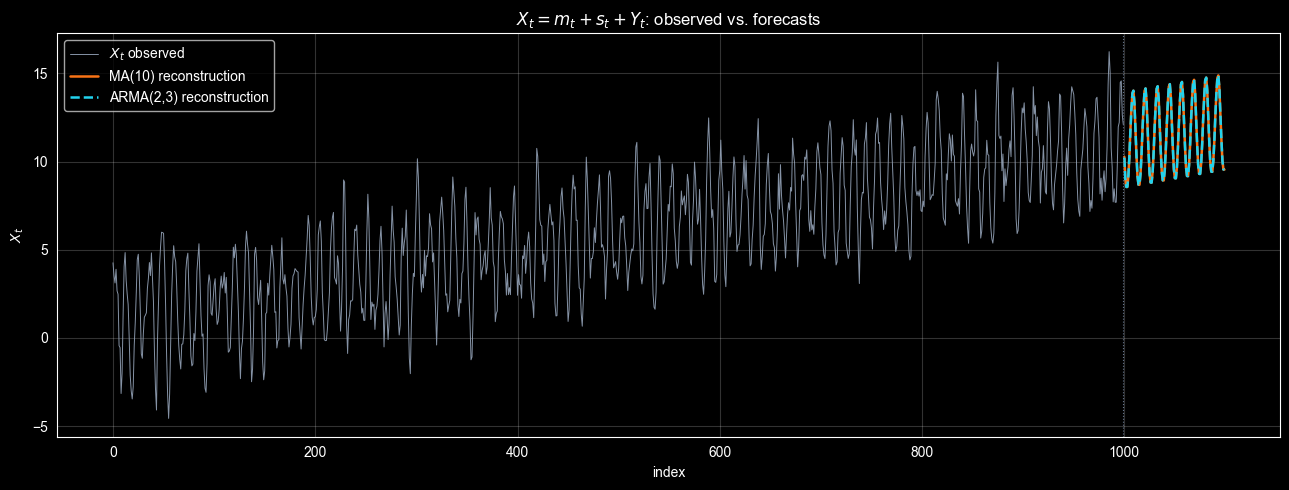

In [119]:
import matplotlib.pyplot as plt

idx_obs = df.index.values

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(idx_obs, df["Xt"].values,
        label="$X_t$ observed", color="#94a3b8", linewidth=0.7, alpha=0.9)
ax.plot(idx_future, X_future_MA,
        label="MA(10) reconstruction", color="#f97316", linewidth=1.8)
ax.plot(idx_future, X_future_ARMA,
        label="ARMA(2,3) reconstruction", color="#22d3ee",
        linewidth=1.8, linestyle="--")
ax.axvline(999, color="#64748b", linestyle=":", linewidth=0.8)

ax.set_xlabel("index")
ax.set_ylabel("$X_t$")
ax.set_title("$X_t = m_t + s_t + Y_t$: observed vs. forecasts")
ax.legend(loc="upper left", frameon=True)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

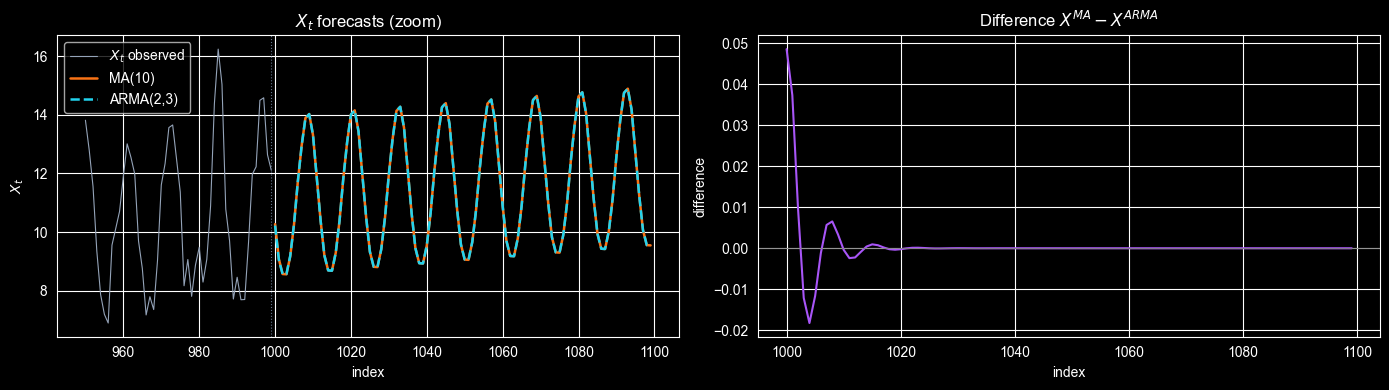

In [121]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: Xt zoomed on the forecast window (last ~50 observed + 100 forecast)
axes[0].plot(idx_obs[-50:], df["Xt"].values[-50:],
             label="$X_t$ observed", color="#94a3b8", linewidth=0.8)
axes[0].plot(idx_future, X_future_MA,
             label="MA(10)", color="#f97316", linewidth=1.8)
axes[0].plot(idx_future, X_future_ARMA,
             label="ARMA(2,3)", color="#22d3ee", linewidth=1.8, linestyle="--")
axes[0].axvline(999, color="#64748b", linestyle=":", linewidth=0.8)
axes[0].set_title("$X_t$ forecasts (zoom)")
axes[0].set_xlabel("index"); axes[0].set_ylabel("$X_t$")
axes[0].legend()

# Right: difference between the two reconstructions
axes[1].plot(idx_future, X_future_MA - X_future_ARMA, color="#a855f7")
axes[1].axhline(0, color="grey", linewidth=0.6)
axes[1].set_title("Difference $X^{MA} - X^{ARMA}$")
axes[1].set_xlabel("index"); axes[1].set_ylabel("difference")

plt.tight_layout()
plt.show()

We can see that the forecast with the MA(10) and the ARMA(2,3) are extremely close; this is due to the fact that $\hat{Y}_{t+h} \to 0$ for both models as $h \to \infty$, since all finite-order ARMA processes converge to their unconditional mean beyond their memory horizon. The forecast of $X_t$ is therefore entirely driven by the extrapolated trend $\hat{m}_t$ and the seasonal component $\hat{s}_t$.